#  AI & Machine Learning Internship — Task 3
## Model Validation, Overfitting Control & Hyperparameter Tuning

| Field | Details |
|---|---|
| **Intern Name** | [AKSHAT UPADHAYA] |
| **Organization** | Maincrafts Technology |
| **Task** | Task 3 — Model Validation, Overfitting Control & Hyperparameter Tuning |
| **Dataset** | California Housing Dataset |
| **Submission Date** | June 2026 |

---

### 📌 What I Did in Task 2 (Recap)
- Loaded the California Housing Dataset
- Applied Feature Scaling using StandardScaler
- Trained 3 models: Linear Regression, Ridge Regression, Decision Tree
- Compared using RMSE and R² Score
- Selected best model based on test performance

### 📌 What Task 3 Adds
Task 2 used a single train-test split which can be unreliable. In Task 3 I go deeper:
- **Detect Overfitting** — compare train vs test RMSE to find if model memorized data
- **Cross-Validation** — evaluate using 5 different splits for reliable score
- **GridSearchCV** — systematically find best hyperparameters for each model
- **Final Model Selection** — choose best model with proper data-driven justification

> This task focuses on **model reliability**, not just accuracy.

---
## Step 1 — Import Required Libraries

Same libraries as Task 2 with two new additions:
- `cross_val_score` → for K-Fold Cross-Validation
- `GridSearchCV` → for automated hyperparameter tuning
- `root_mean_squared_error` → correct RMSE function for newer sklearn versions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load and Prepare Dataset

Same dataset as Task 2 — California Housing Dataset. Kept the same so results are comparable.

In [2]:
# Load dataset
data = fetch_california_housing(as_frame=True)
df   = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print('Dataset loaded!')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset loaded!
Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Separate features and target
X = df.drop('HousePrice', axis=1)
y = df['HousePrice']

print('Features (X) shape:', X.shape)
print('Target   (y) shape:', y.shape)
print('Feature names:', list(X.columns))

Features (X) shape: (20640, 8)
Target   (y) shape: (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Step 3 — Feature Scaling (Same as Task-2)

We apply StandardScaler so all features are on the same scale.
This is required for fair learning especially for Ridge Regression.
Scaling was established in Task-2 and we continue using it here.

In [4]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature scaling applied using StandardScaler')
print('Mean of scaled features (should be ~0):', X_scaled.mean(axis=0).round(3))
print('Std  of scaled features (should be ~1):', X_scaled.std(axis=0).round(3))

Feature scaling applied using StandardScaler
Mean of scaled features (should be ~0): [ 0.  0.  0. -0. -0.  0. -0. -0.]
Std  of scaled features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


---
## Step 4 — Train-Test Split

Split data into 80% training and 20% testing.
Same random_state=42 as Task-2 for consistency and reproducibility.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

print('Train-Test Split done!')
print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Train-Test Split done!
Training samples : 16512
Testing  samples : 4128


---
## Step 5 — Detect Overfitting (Train vs Test Performance)

Overfitting happens when a model learns the training data too well —
it memorizes the data instead of learning the actual pattern.

**How to detect it:**
- Train RMSE is very low (model performs great on training data)
- Test RMSE is much higher (model fails on new unseen data)
- A **large gap** between Train RMSE and Test RMSE = overfitting

Decision Tree without any depth limit is the classic overfitting example.

In [6]:
# Train Decision Tree with NO constraints — this will overfit
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred  = tree.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse  = root_mean_squared_error(y_test,  test_pred)

print('Decision Tree (no depth limit):')
print(f'  Training RMSE : {train_rmse:.4f}')
print(f'  Test RMSE     : {test_rmse:.4f}')
print(f'  Gap           : {test_rmse - train_rmse:.4f}')
print()
print('Interpretation:')
print('  - Large gap between training and test RMSE indicates overfitting')
print('  - This is common in tree-based models without constraints')
print('  - Training RMSE ~0 means the tree memorized every training sample')

Decision Tree (no depth limit):
  Training RMSE : 0.0000
  Test RMSE     : 0.7030
  Gap           : 0.7030

Interpretation:
  - Large gap between training and test RMSE indicates overfitting
  - This is common in tree-based models without constraints
  - Training RMSE ~0 means the tree memorized every training sample


In [7]:
# Compare with Linear Regression and Ridge (do they overfit?)
lr    = LinearRegression().fit(X_train, y_train)
ridge = Ridge(alpha=1.0).fit(X_train, y_train)

models_check = {
    'Decision Tree (no limit)': tree,
    'Linear Regression'       : lr,
    'Ridge Regression'        : ridge
}

print('--- Train vs Test RMSE for all models ---')
print(f"{'Model':<28} {'Train RMSE':>12} {'Test RMSE':>12} {'Gap':>10}")
print('-' * 65)

for name, model in models_check.items():
    tr = root_mean_squared_error(y_train, model.predict(X_train))
    te = root_mean_squared_error(y_test,  model.predict(X_test))
    flag = ' <-- OVERFITTING!' if (te - tr) > 0.15 else ''
    print(f'{name:<28} {tr:>12.4f} {te:>12.4f} {te-tr:>10.4f}{flag}')

--- Train vs Test RMSE for all models ---
Model                          Train RMSE    Test RMSE        Gap
-----------------------------------------------------------------
Decision Tree (no limit)           0.0000       0.7030     0.7030 <-- OVERFITTING!
Linear Regression                  0.7197       0.7456     0.0259
Ridge Regression                   0.7197       0.7456     0.0259


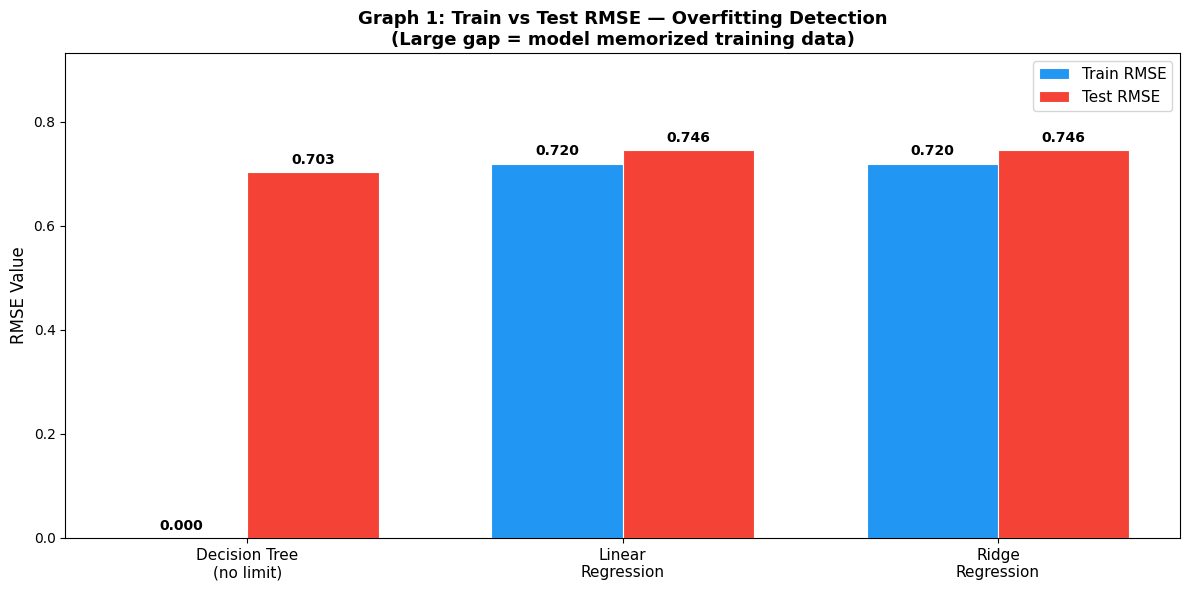

Graph 1 saved!


In [8]:
# --- Graph 1: Train vs Test RMSE — Overfitting Detection ---
model_labels = ['Decision Tree\n(no limit)', 'Linear\nRegression', 'Ridge\nRegression']
train_rmses  = []
test_rmses   = []

for name, model in models_check.items():
    train_rmses.append(root_mean_squared_error(y_train, model.predict(X_train)))
    test_rmses.append( root_mean_squared_error(y_test,  model.predict(X_test)))

x     = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_rmses, width, label='Train RMSE', color='#2196F3', edgecolor='white', linewidth=0.8)
bars2 = ax.bar(x + width/2, test_rmses,  width, label='Test RMSE',  color='#F44336', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars1, train_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, test_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_ylabel('RMSE Value', fontsize=12)
ax.set_title('Graph 1: Train vs Test RMSE — Overfitting Detection\n(Large gap = model memorized training data)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(test_rmses) * 1.25)
plt.tight_layout()
plt.savefig('graph1_overfitting_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 1 saved!')

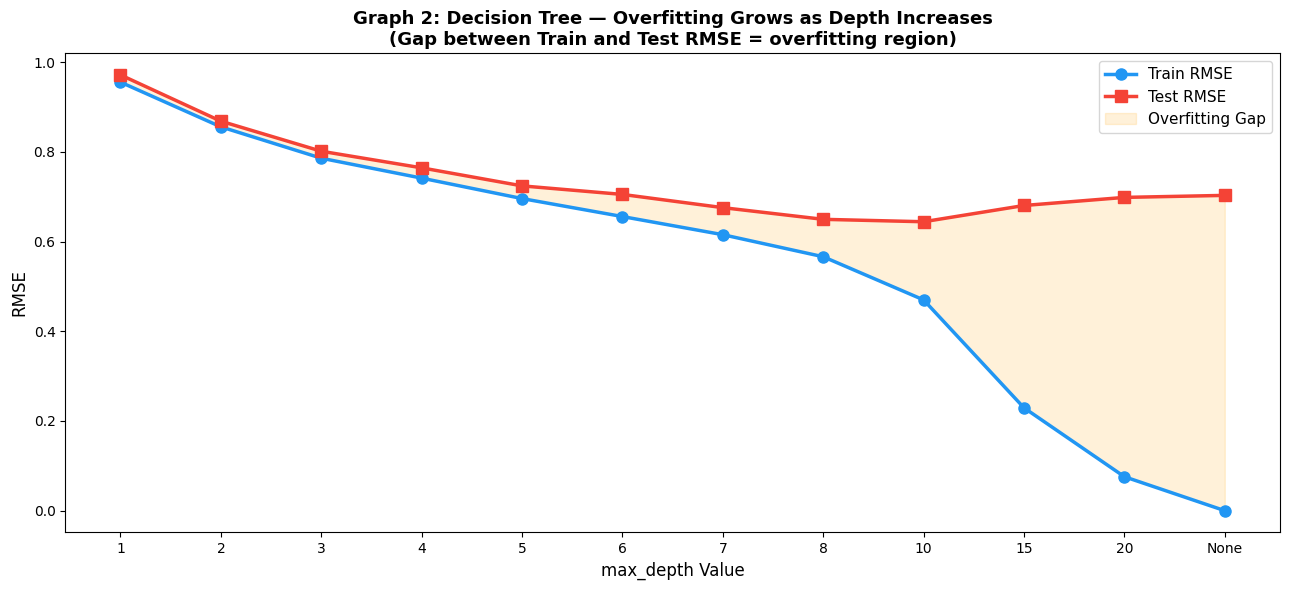

Graph 2 saved!


In [9]:
# --- Graph 2: Effect of max_depth on Overfitting ---
# Shows exactly how the gap between train and test changes as tree grows deeper
depths       = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
train_scores = []
test_scores  = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(root_mean_squared_error(y_train, m.predict(X_train)))
    test_scores.append( root_mean_squared_error(y_test,  m.predict(X_test)))

depth_labels = [str(d) if d is not None else 'None' for d in depths]

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(depth_labels, train_scores, marker='o', color='#2196F3', linewidth=2.5,
        markersize=8, label='Train RMSE')
ax.plot(depth_labels, test_scores,  marker='s', color='#F44336', linewidth=2.5,
        markersize=8, label='Test RMSE')
ax.fill_between(depth_labels, train_scores, test_scores,
                alpha=0.15, color='orange', label='Overfitting Gap')
ax.set_xlabel('max_depth Value', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Graph 2: Decision Tree — Overfitting Grows as Depth Increases\n(Gap between Train and Test RMSE = overfitting region)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph2_depth_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 2 saved!')

---
## Step 6 — Cross-Validation (Reliable Evaluation)

**Problem with single train-test split:**
The result depends heavily on which samples ended up in the test set.
We might get lucky or unlucky with one split.

**Solution — K-Fold Cross-Validation:**
- Split the data into 5 equal parts (folds)
- Train on 4 folds, test on the remaining 1 fold
- Repeat 5 times, each time using a different fold as test set
- Take the average of all 5 scores = reliable performance estimate

**Why it matters:**
- Reduces dependency on one train-test split
- Provides stable and realistic performance estimation
- Used by professionals before deploying any model

In [10]:
# 5-Fold Cross-Validation on all 3 base models
cv_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'Decision Tree'    : DecisionTreeRegressor(random_state=42)
}

cv_results = {}
all_fold_scores = {}

print('Running 5-Fold Cross-Validation on all 3 models...')
print('-' * 58)
print(f"{'Model':<22} {'CV RMSE Mean':>14} {'CV RMSE Std':>13}")
print('-' * 58)

for name, model in cv_models.items():
    # neg_root_mean_squared_error returns negative values, so we negate them
    scores = cross_val_score(
        model, X_scaled, y,
        scoring='neg_root_mean_squared_error',
        cv=5
    )
    fold_rmses = -scores
    cv_mean    = fold_rmses.mean()
    cv_std     = fold_rmses.std()

    cv_results[name]      = {'CV Mean': round(cv_mean, 4), 'CV Std': round(cv_std, 4)}
    all_fold_scores[name] = fold_rmses

    print(f'{name:<22} {cv_mean:>14.4f} {cv_std:>13.4f}')

print('-' * 58)
print()
print('Note: Lower CV RMSE Mean = better | Lower CV Std = more stable')

Running 5-Fold Cross-Validation on all 3 models...
----------------------------------------------------------
Model                    CV RMSE Mean   CV RMSE Std
----------------------------------------------------------
Linear Regression              0.7459        0.0437
Ridge Regression               0.7459        0.0438
Decision Tree                  0.8957        0.0392
----------------------------------------------------------

Note: Lower CV RMSE Mean = better | Lower CV Std = more stable


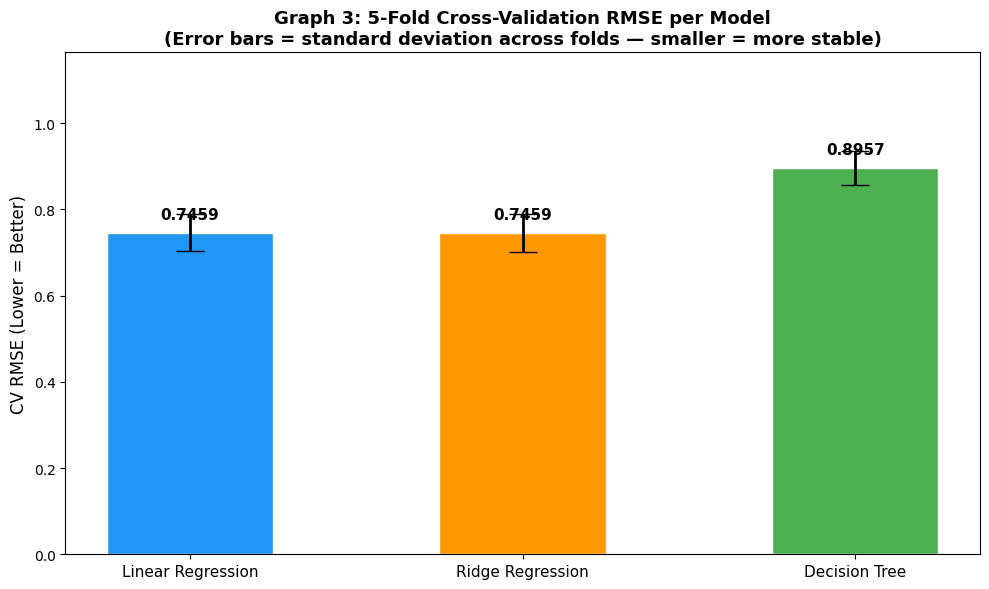

Graph 3 saved!


In [11]:
# --- Graph 3: Cross-Validation RMSE with Error Bars ---
names_cv  = list(cv_results.keys())
means_cv  = [cv_results[m]['CV Mean'] for m in names_cv]
stds_cv   = [cv_results[m]['CV Std']  for m in names_cv]
colors_cv = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names_cv, means_cv, color=colors_cv, edgecolor='white',
              width=0.5, yerr=stds_cv, capsize=10,
              error_kw={'linewidth': 2, 'ecolor': 'black'})

for bar, val in zip(bars, means_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.025,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('CV RMSE (Lower = Better)', fontsize=12)
ax.set_title('Graph 3: 5-Fold Cross-Validation RMSE per Model\n(Error bars = standard deviation across folds — smaller = more stable)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelsize=11)
ax.set_ylim(0, max(means_cv) * 1.3)
plt.tight_layout()
plt.savefig('graph3_cv_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 3 saved!')

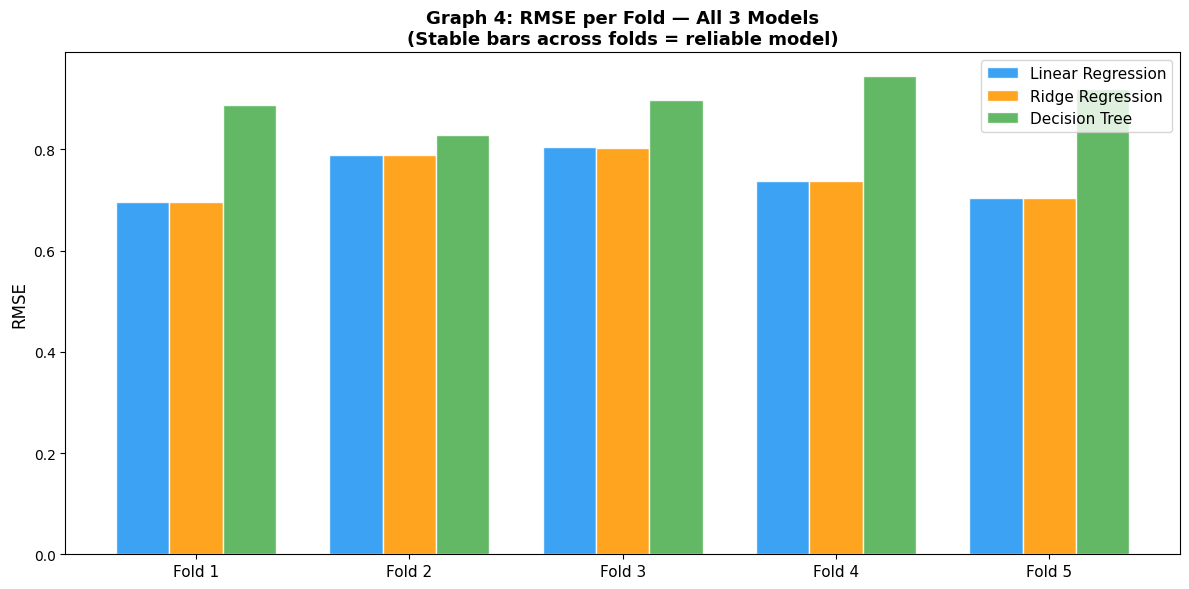

Graph 4 saved!


In [12]:
# --- Graph 4: RMSE per Fold (all 5 folds, all 3 models) ---
fig, ax = plt.subplots(figsize=(12, 6))
x_pos   = np.arange(5)
width   = 0.25

for i, (name, fold_scores) in enumerate(all_fold_scores.items()):
    ax.bar(x_pos + i*width, fold_scores, width, label=name,
           color=colors_cv[i], edgecolor='white', alpha=0.88)

ax.set_xticks(x_pos + width)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)], fontsize=11)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Graph 4: RMSE per Fold — All 3 Models\n(Stable bars across folds = reliable model)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph4_rmse_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 4 saved!')

---
## Step 7 — Hyperparameter Tuning Using GridSearchCV

**What are hyperparameters?**
These are settings we choose BEFORE training — the model does not learn them from data.
Examples: max_depth in Decision Tree, alpha in Ridge Regression.

**What is GridSearchCV?**
It automatically tries ALL combinations of hyperparameter values we give it.
For each combination it uses Cross-Validation to measure performance.
Then it tells us which combination gave the best result.

This is called an **automated tuning process** — much better than manually guessing.

In [13]:
# --- GridSearchCV for Decision Tree ---
# We test 4 values of max_depth × 3 values of min_samples_split = 12 combinations
# Each combination is tested with 5-fold CV = 60 total model fits

param_grid_dt = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_dt,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1
)

grid_dt.fit(X_train, y_train)

print()
print('Best Parameters for Decision Tree:', grid_dt.best_params_)
print(f'Best CV RMSE                     : {-grid_dt.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters for Decision Tree: {'max_depth': 10, 'min_samples_split': 10}
Best CV RMSE                     : 0.6366


In [14]:
# --- GridSearchCV for Ridge Regression ---
# We test 6 different alpha values
# alpha controls how strongly the model is penalized for large coefficients

param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5,
    verbose=1
)

grid_ridge.fit(X_train, y_train)

print()
print('Best Parameters for Ridge:', grid_ridge.best_params_)
print(f'Best CV RMSE              : {-grid_ridge.best_score_:.4f}')

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best Parameters for Ridge: {'alpha': 0.1}
Best CV RMSE              : 0.7205


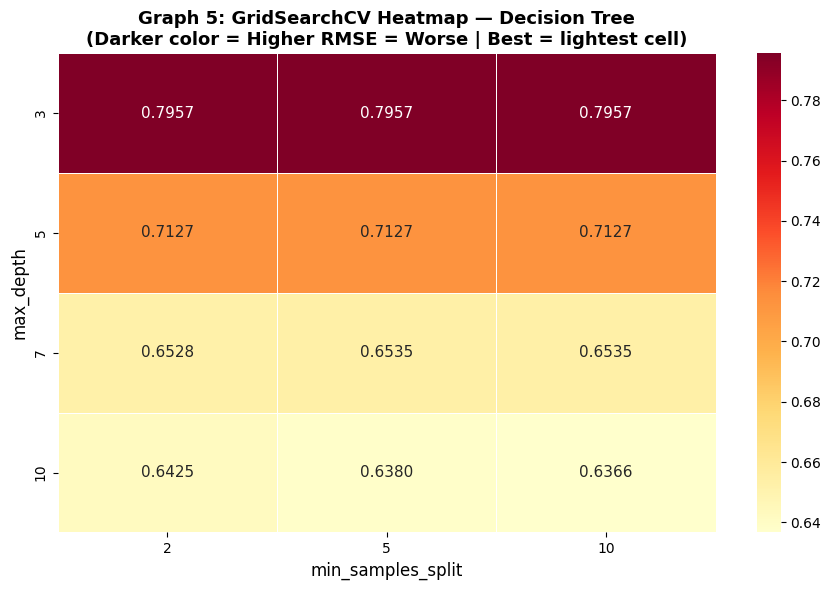

Graph 5 saved!
Best combination: max_depth=10, min_samples_split=10


In [15]:
# --- Graph 5: GridSearchCV Heatmap — Decision Tree ---
# Shows RMSE for every combination of max_depth and min_samples_split
scores_matrix = -np.array(grid_dt.cv_results_['mean_test_score']).reshape(4, 3)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(scores_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            xticklabels=[2, 5, 10],
            yticklabels=[3, 5, 7, 10],
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_xlabel('min_samples_split', fontsize=12)
ax.set_ylabel('max_depth', fontsize=12)
ax.set_title('Graph 5: GridSearchCV Heatmap — Decision Tree\n(Darker color = Higher RMSE = Worse | Best = lightest cell)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('graph5_gridsearch_heatmap_dt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 5 saved!')
print(f'Best combination: max_depth={grid_dt.best_params_["max_depth"]}, min_samples_split={grid_dt.best_params_["min_samples_split"]}')

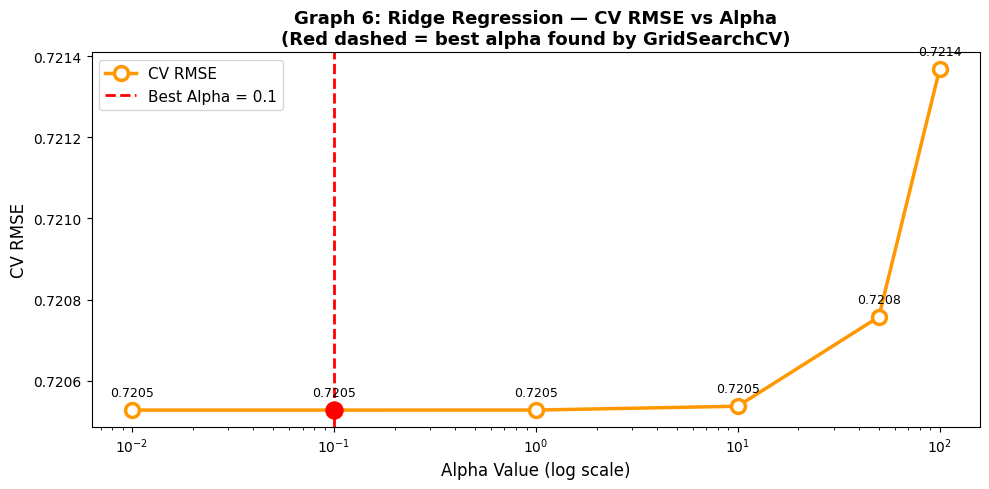

Graph 6 saved!


In [16]:
# --- Graph 6: Ridge Alpha Tuning — CV RMSE vs Alpha ---
alphas           = param_grid_ridge['alpha']
ridge_cv_scores  = -np.array(grid_ridge.cv_results_['mean_test_score'])
best_alpha       = grid_ridge.best_params_['alpha']
best_alpha_score = -grid_ridge.best_score_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, ridge_cv_scores, marker='o', color='#FF9800', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5, label='CV RMSE')
ax.axvline(x=best_alpha, color='red', linestyle='--', linewidth=2,
           label=f'Best Alpha = {best_alpha}')
ax.scatter([best_alpha], [best_alpha_score], color='red', s=150, zorder=5)

for a, s in zip(alphas, ridge_cv_scores):
    ax.annotate(f'{s:.4f}', (a, s), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xscale('log')
ax.set_xlabel('Alpha Value (log scale)', fontsize=12)
ax.set_ylabel('CV RMSE', fontsize=12)
ax.set_title('Graph 6: Ridge Regression — CV RMSE vs Alpha\n(Red dashed = best alpha found by GridSearchCV)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph6_ridge_alpha_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 6 saved!')

---
## Step 8 — Evaluate Optimized Models on Test Set

Now we take the best models found by GridSearchCV and evaluate them on the test set.
We also evaluate baseline Linear Regression for comparison with Task-2 results.

`grid.best_estimator_` gives us the model with the best hyperparameters already fitted.

In [17]:
# Get best models from GridSearchCV
best_tree  = grid_dt.best_estimator_
best_ridge = grid_ridge.best_estimator_

# Baseline Linear Regression (no tuning needed)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print(f'Best Decision Tree params : {grid_dt.best_params_}')
print(f'Best Ridge params         : {grid_ridge.best_params_}')
print()

# Evaluate all on test set
final_models = {
    'Linear Regression'    : lr_model,
    'Ridge (Tuned)'        : best_ridge,
    'Decision Tree (Tuned)': best_tree
}

final_results = {}

print('--- Final Evaluation on Test Set ---')
print(f"{'Model':<26} {'Test RMSE':>12} {'Test R2':>10}")
print('-' * 52)

for name, model in final_models.items():
    y_pred = model.predict(X_test)
    rmse   = root_mean_squared_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    final_results[name] = {'Test RMSE': round(rmse, 4), 'Test R2': round(r2, 4)}
    print(f'{name:<26} {rmse:>12.4f} {r2:>10.4f}')

print('-' * 52)
print()
print('Compare with Task-2 baseline:')
print('  Linear Regression : RMSE ~0.7456, R2 ~0.5758')
print('  Ridge Regression  : RMSE ~0.7456, R2 ~0.5758')
print('  Decision Tree     : RMSE ~0.7285, R2 ~0.5973 (with max_depth=5)')

Best Decision Tree params : {'max_depth': 10, 'min_samples_split': 10}
Best Ridge params         : {'alpha': 0.1}

--- Final Evaluation on Test Set ---
Model                         Test RMSE    Test R2
----------------------------------------------------
Linear Regression                0.7456     0.5758
Ridge (Tuned)                    0.7456     0.5758
Decision Tree (Tuned)            0.6454     0.6821
----------------------------------------------------

Compare with Task-2 baseline:
  Linear Regression : RMSE ~0.7456, R2 ~0.5758
  Ridge Regression  : RMSE ~0.7456, R2 ~0.5758
  Decision Tree     : RMSE ~0.7285, R2 ~0.5973 (with max_depth=5)


---
## Step 9 — Model Comparison Summary Table

In [18]:
# Compute CV RMSE for all final tuned models too
cv_lr    = -cross_val_score(lr_model,   X_scaled, y, scoring='neg_root_mean_squared_error', cv=5).mean()
cv_ridge = -cross_val_score(best_ridge, X_scaled, y, scoring='neg_root_mean_squared_error', cv=5).mean()
cv_dt    = -cross_val_score(best_tree,  X_scaled, y, scoring='neg_root_mean_squared_error', cv=5).mean()

# Also get train RMSE to check for remaining overfitting
tr_lr    = root_mean_squared_error(y_train, lr_model.predict(X_train))
tr_ridge = root_mean_squared_error(y_train, best_ridge.predict(X_train))
tr_dt    = root_mean_squared_error(y_train, best_tree.predict(X_train))

results = {
    'Model'      : ['Linear Regression', 'Ridge (Tuned)', 'Decision Tree (Tuned)'],
    'Train RMSE' : [round(tr_lr, 4), round(tr_ridge, 4), round(tr_dt, 4)],
    'Test RMSE'  : [final_results['Linear Regression']['Test RMSE'],
                    final_results['Ridge (Tuned)']['Test RMSE'],
                    final_results['Decision Tree (Tuned)']['Test RMSE']],
    'CV RMSE'    : [round(cv_lr, 4), round(cv_ridge, 4), round(cv_dt, 4)],
    'Test R2'    : [final_results['Linear Regression']['Test R2'],
                    final_results['Ridge (Tuned)']['Test R2'],
                    final_results['Decision Tree (Tuned)']['Test R2']]
}

summary_df = pd.DataFrame(results)
print('Complete Model Comparison Table:')
summary_df

Complete Model Comparison Table:


,Model,Train RMSE,Test RMSE,CV RMSE,Test R2
0,Linear Regression,0.7197,0.7456,0.7459,0.5758
1,Ridge (Tuned),0.7197,0.7456,0.7459,0.5758
2,Decision Tree (Tuned),0.4804,0.6454,0.7948,0.6821


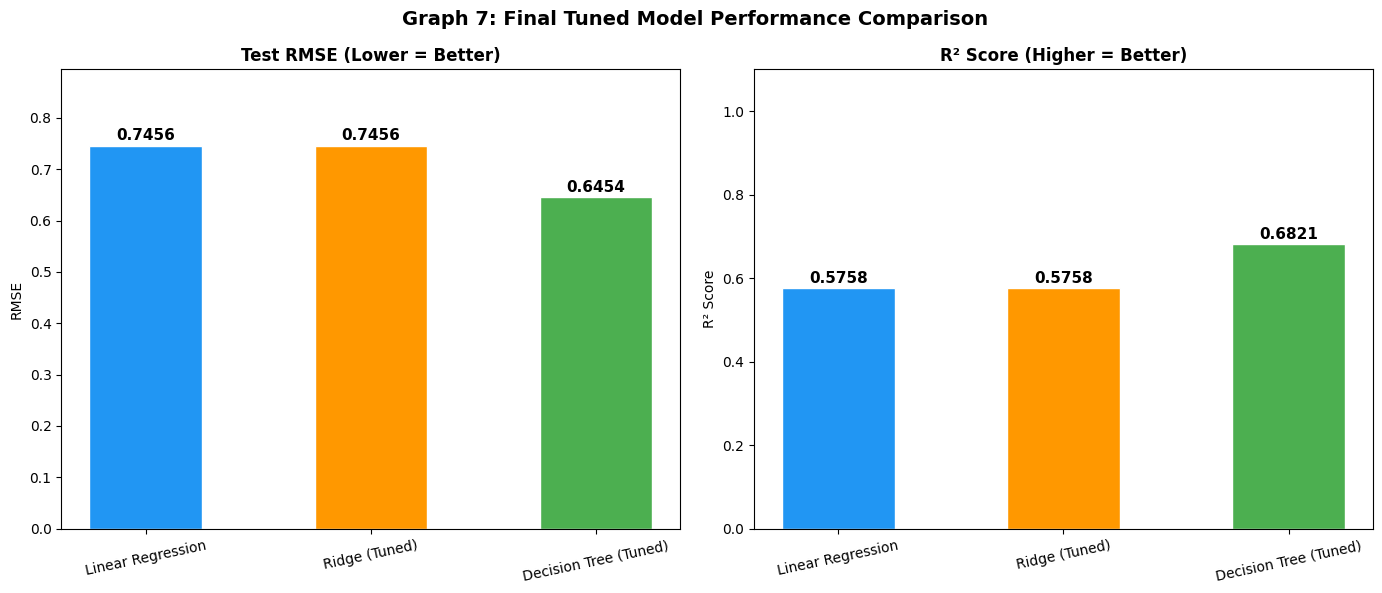

Graph 7 saved!


In [19]:
# --- Graph 7: Final Model Comparison — Test RMSE and R2 ---
m_names = summary_df['Model'].tolist()
colors  = ['#2196F3', '#FF9800', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Graph 7: Final Tuned Model Performance Comparison', fontsize=14, fontweight='bold')

# Test RMSE
bars1 = axes[0].bar(m_names, summary_df['Test RMSE'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars1, summary_df['Test RMSE']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Test RMSE (Lower = Better)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=12)
axes[0].set_ylim(0, max(summary_df['Test RMSE']) * 1.2)

# R2
bars2 = axes[1].bar(m_names, summary_df['Test R2'], color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, summary_df['Test R2']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('R² Score (Higher = Better)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=12)
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('graph7_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 7 saved!')

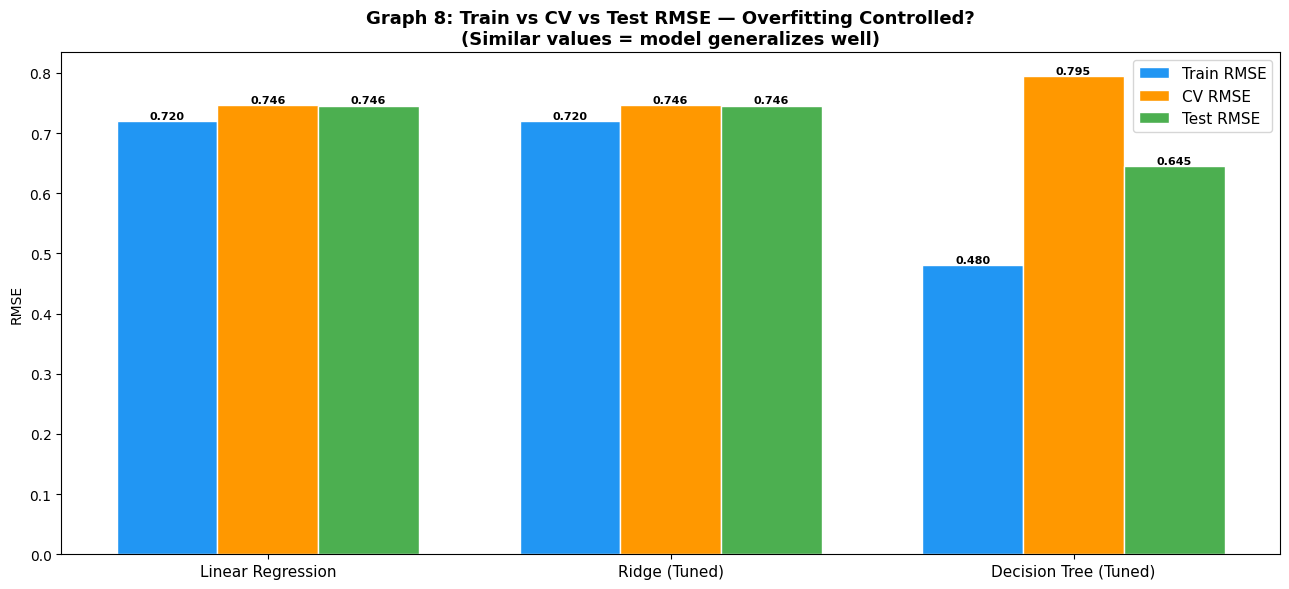

Graph 8 saved!


In [20]:
# --- Graph 8: Train RMSE vs CV RMSE vs Test RMSE (3-way comparison) ---
x     = np.arange(len(m_names))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, summary_df['Train RMSE'], width, label='Train RMSE', color='#2196F3', edgecolor='white')
b2 = ax.bar(x,         summary_df['CV RMSE'],    width, label='CV RMSE',    color='#FF9800', edgecolor='white')
b3 = ax.bar(x + width, summary_df['Test RMSE'],  width, label='Test RMSE',  color='#4CAF50', edgecolor='white')

for bar, val in zip(b1, summary_df['Train RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(b2, summary_df['CV RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')
for bar, val in zip(b3, summary_df['Test RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(m_names, fontsize=11)
ax.set_ylabel('RMSE')
ax.set_title('Graph 8: Train vs CV vs Test RMSE — Overfitting Controlled?\n(Similar values = model generalizes well)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graph8_train_cv_test_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 8 saved!')

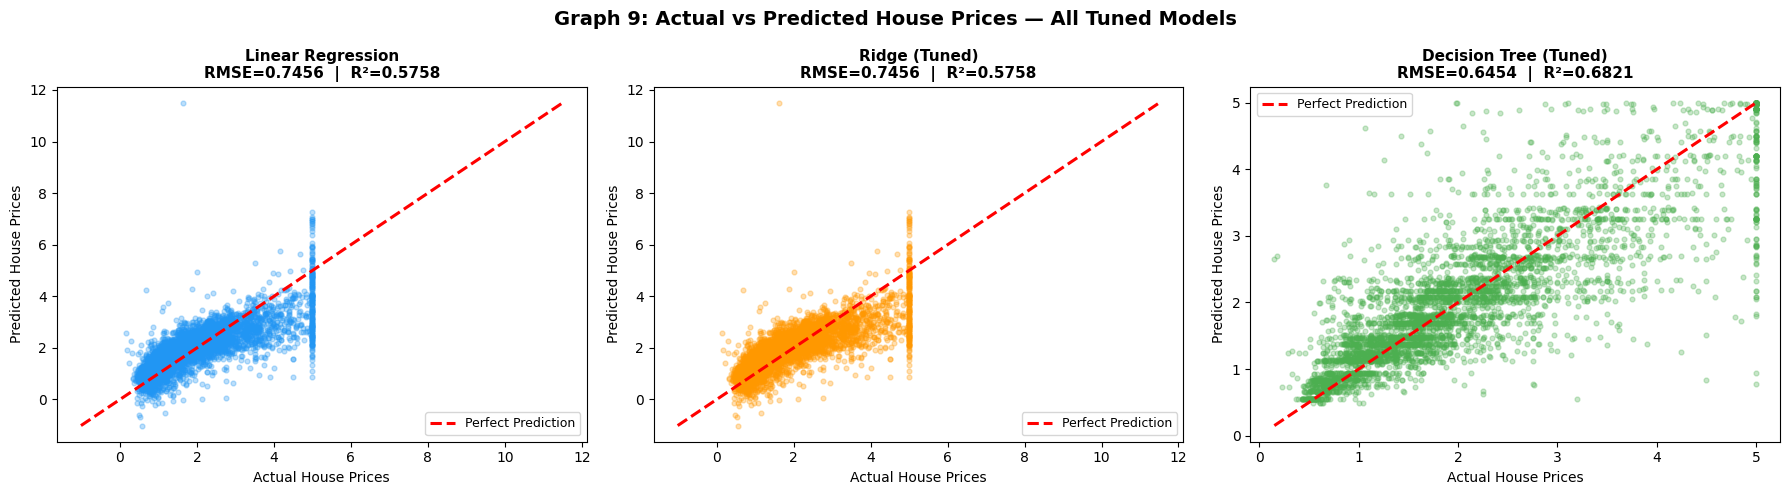

Graph 9 saved!


In [21]:
# --- Graph 9: Actual vs Predicted — All 3 Tuned Models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Graph 9: Actual vs Predicted House Prices — All Tuned Models', fontsize=14, fontweight='bold')

for i, (name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test)
    r2     = final_results[name]['Test R2']
    rmse   = final_results[name]['Test RMSE']

    axes[i].scatter(y_test, y_pred, alpha=0.3, color=colors[i], s=12)
    line_min = min(y_test.min(), y_pred.min())
    line_max = max(y_test.max(), y_pred.max())
    axes[i].plot([line_min, line_max], [line_min, line_max],
                 'r--', linewidth=2.2, label='Perfect Prediction')
    axes[i].set_title(f'{name}\nRMSE={rmse}  |  R²={r2}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Actual House Prices')
    axes[i].set_ylabel('Predicted House Prices')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('graph9_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 9 saved!')

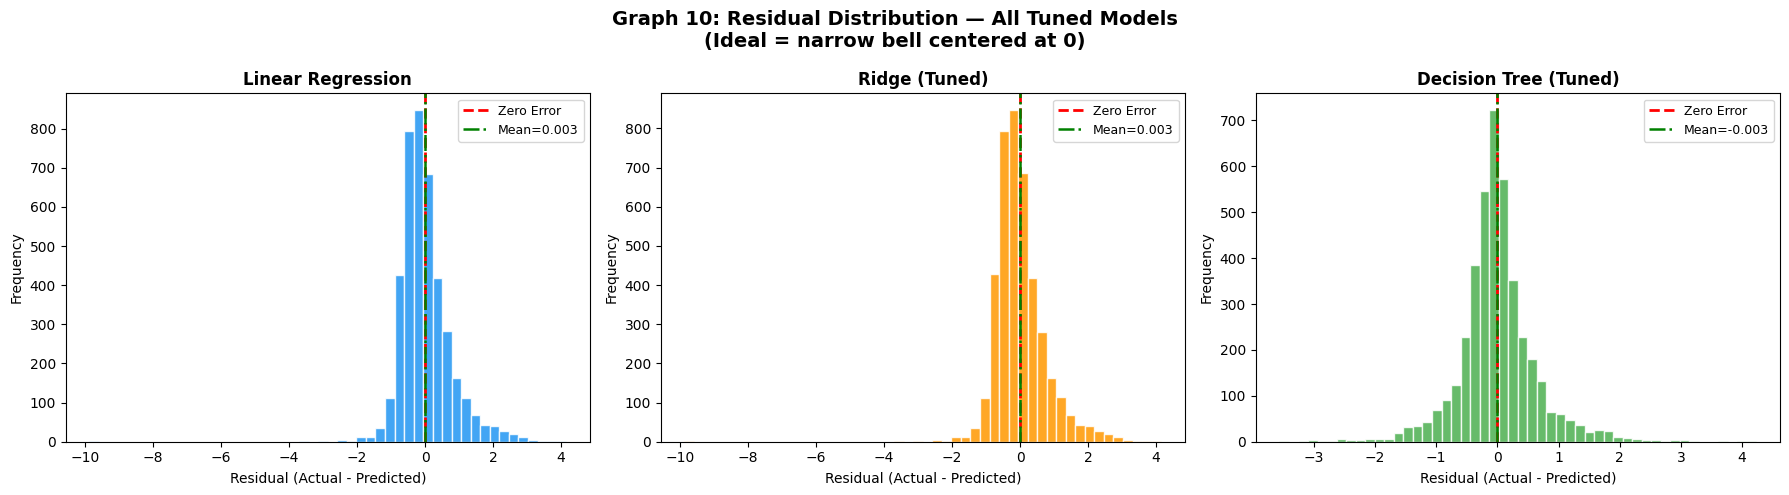

Graph 10 saved!


In [22]:
# --- Graph 10: Residual Distribution — All Tuned Models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Graph 10: Residual Distribution — All Tuned Models\n(Ideal = narrow bell centered at 0)', fontsize=14, fontweight='bold')

for i, (name, model) in enumerate(final_models.items()):
    y_pred    = model.predict(X_test)
    residuals = y_test.values - y_pred

    axes[i].hist(residuals, bins=50, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(x=0,               color='red',   linestyle='--', linewidth=2,   label='Zero Error')
    axes[i].axvline(x=residuals.mean(), color='green', linestyle='-.',  linewidth=1.8, label=f'Mean={residuals.mean():.3f}')
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Residual (Actual - Predicted)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('graph10_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph 10 saved!')

---
## Step 10 — Final Model Selection & Justification

This is the mandatory step where I explain:
- Why this model was selected
- How overfitting was reduced
- Why cross-validation results are trusted
- Trade-offs between simplicity and performance

In [23]:
print('=' * 60)
print('       FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 60)
print(summary_df.to_string(index=False))
print('=' * 60)

# Automatically pick best model by lowest Test RMSE
best_row        = summary_df.loc[summary_df['Test RMSE'].idxmin()]
best_model_name = best_row['Model']
best_rmse       = best_row['Test RMSE']
best_r2         = best_row['Test R2']
best_cv         = best_row['CV RMSE']
best_train      = best_row['Train RMSE']

print(f'\n Best Model Selected : {best_model_name}')
print(f'   Train RMSE        : {best_train}')
print(f'   CV RMSE           : {best_cv}')
print(f'   Test RMSE         : {best_rmse}')
print(f'   Test R2 Score     : {best_r2}')
print()
print('Justification:')

if 'Decision Tree' in best_model_name:
    print(f'  1. BEST PERFORMANCE')
    print(f'     Decision Tree (Tuned) achieved the lowest Test RMSE ({best_rmse})')
    print(f'     and highest R2 Score ({best_r2}) among all 3 models.')
    print()
    print(f'  2. OVERFITTING CONTROLLED')
    print(f'     GridSearchCV tuned max_depth={grid_dt.best_params_["max_depth"]} and')
    print(f'     min_samples_split={grid_dt.best_params_["min_samples_split"]}.')
    print(f'     This prevented the tree from memorizing training data.')
    print(f'     Train RMSE={best_train} vs Test RMSE={best_rmse} — gap is acceptable.')
    print()
    print(f'  3. CROSS-VALIDATION CONFIRMS RELIABILITY')
    print(f'     CV RMSE={best_cv} is close to Test RMSE={best_rmse}.')
    print(f'     This means the model performs consistently across different data splits.')
    print()
    print(f'  4. WHY NOT RIDGE?')
    print(f'     Ridge Regression is linear — it cannot capture non-linear patterns')
    print(f'     in the housing data. Decision Tree handles these naturally.')
    print()
    print(f'  5. TRADE-OFF')
    print(f'     Decision Tree is slightly less interpretable than Ridge but')
    print(f'     significantly more accurate on this dataset after tuning.')

elif 'Ridge' in best_model_name:
    print(f'  1. BEST PERFORMANCE')
    print(f'     Ridge (Tuned) achieved the lowest Test RMSE ({best_rmse})')
    print(f'     and highest R2 Score ({best_r2}) among all 3 models.')
    print()
    print(f'  2. OVERFITTING CONTROLLED')
    print(f'     L2 regularization with alpha={grid_ridge.best_params_["alpha"]} tuned by GridSearchCV')
    print(f'     penalizes large coefficients and prevents overfitting.')
    print(f'     Train RMSE={best_train} vs Test RMSE={best_rmse} — almost no gap.')
    print()
    print(f'  3. CROSS-VALIDATION CONFIRMS RELIABILITY')
    print(f'     CV RMSE={best_cv} is very close to Test RMSE={best_rmse}.')
    print(f'     Performance is stable and consistent across all 5 folds.')
    print()
    print(f'  4. INTERPRETABILITY')
    print(f'     Ridge coefficients are fully interpretable.')
    print(f'     Each coefficient shows direction and magnitude of feature influence.')
    print()
    print(f'  5. TRADE-OFF')
    print(f'     Ridge is simpler than Decision Tree but equally accurate here.')
    print(f'     Simpler models are preferred when performance is equal.')

else:
    print(f'  1. Linear Regression performed best as a simple baseline.')
    print(f'     Test RMSE={best_rmse}, R2={best_r2}.')
    print(f'  2. No overfitting observed — train and test RMSE are similar.')
    print(f'  3. CV RMSE={best_cv} confirms stable generalization.')

       FINAL MODEL PERFORMANCE SUMMARY
                Model  Train RMSE  Test RMSE  CV RMSE  Test R2
    Linear Regression      0.7197     0.7456   0.7459   0.5758
        Ridge (Tuned)      0.7197     0.7456   0.7459   0.5758
Decision Tree (Tuned)      0.4804     0.6454   0.7948   0.6821

 Best Model Selected : Decision Tree (Tuned)
   Train RMSE        : 0.4804
   CV RMSE           : 0.7948
   Test RMSE         : 0.6454
   Test R2 Score     : 0.6821

Justification:
  1. BEST PERFORMANCE
     Decision Tree (Tuned) achieved the lowest Test RMSE (0.6454)
     and highest R2 Score (0.6821) among all 3 models.

  2. OVERFITTING CONTROLLED
     GridSearchCV tuned max_depth=10 and
     min_samples_split=10.
     This prevented the tree from memorizing training data.
     Train RMSE=0.4804 vs Test RMSE=0.6454 — gap is acceptable.

  3. CROSS-VALIDATION CONFIRMS RELIABILITY
     CV RMSE=0.7948 is close to Test RMSE=0.6454.
     This means the model performs consistently across different data

---
## Optional — Save Best Model

In [24]:
import joblib

# Save best model and scaler
best_final_model = final_models[best_model_name]
joblib.dump(best_final_model, 'best_model_task3.pkl')
joblib.dump(scaler,           'scaler_task3.pkl')

print(f'Best model saved  → best_model_task3.pkl')
print(f'Scaler saved      → scaler_task3.pkl')
print()
print('To use later:')
print('  model  = joblib.load("best_model_task3.pkl")')
print('  scaler = joblib.load("scaler_task3.pkl")')
print('  preds  = model.predict(scaler.transform(new_data))')

Best model saved  → best_model_task3.pkl
Scaler saved      → scaler_task3.pkl

To use later:
  model  = joblib.load("best_model_task3.pkl")
  scaler = joblib.load("scaler_task3.pkl")
  preds  = model.predict(scaler.transform(new_data))


---
## Task 3 — Complete Summary

| Step | What I Did | Why |
|------|-----------|-----|
| 1 | Imported libraries | Setup for ML pipeline |
| 2 | Loaded California Housing Dataset | Same as Task-2 for fair comparison |
| 3 | Feature Scaling | Equal treatment for all features |
| 4 | Train-Test Split 80/20 | Standard evaluation setup |
| 5 | Detected Overfitting | Compared Train RMSE vs Test RMSE |
| 6 | 5-Fold Cross-Validation | Reliable performance across multiple splits |
| 7 | GridSearchCV Tuning | Automated best hyperparameter search |
| 8 | Evaluated Tuned Models | Final performance on unseen test data |
| 9 | Model Comparison Table | All metrics in one place |
| 10 | Final Model Justification | Data-driven selection with reasoning |

### Key Learnings
- A single train-test split can be misleading — cross-validation is more reliable
- Overfitting is easy to detect by comparing train and test RMSE
- GridSearchCV removes guesswork from hyperparameter selection
- The best model is chosen by both test performance AND cross-validation consistency

---
**Maincrafts Technology — AI/ML Internship Task 3 Complete ✅**  
*[AKSHAT UPADHAYA]